Initiating Factor Backtest: 123 Periods | Universe: CSI 300
Status: 2016-12-01 processed successfully.
Status: 2017-12-01 processed successfully.
Status: 2018-12-01 processed successfully.
Status: 2019-12-01 processed successfully.
Status: 2020-12-01 processed successfully.
Status: 2021-12-01 processed successfully.
Status: 2022-12-01 processed successfully.
Status: 2023-12-01 processed successfully.
Status: 2024-12-01 processed successfully.
Status: 2025-12-01 processed successfully.


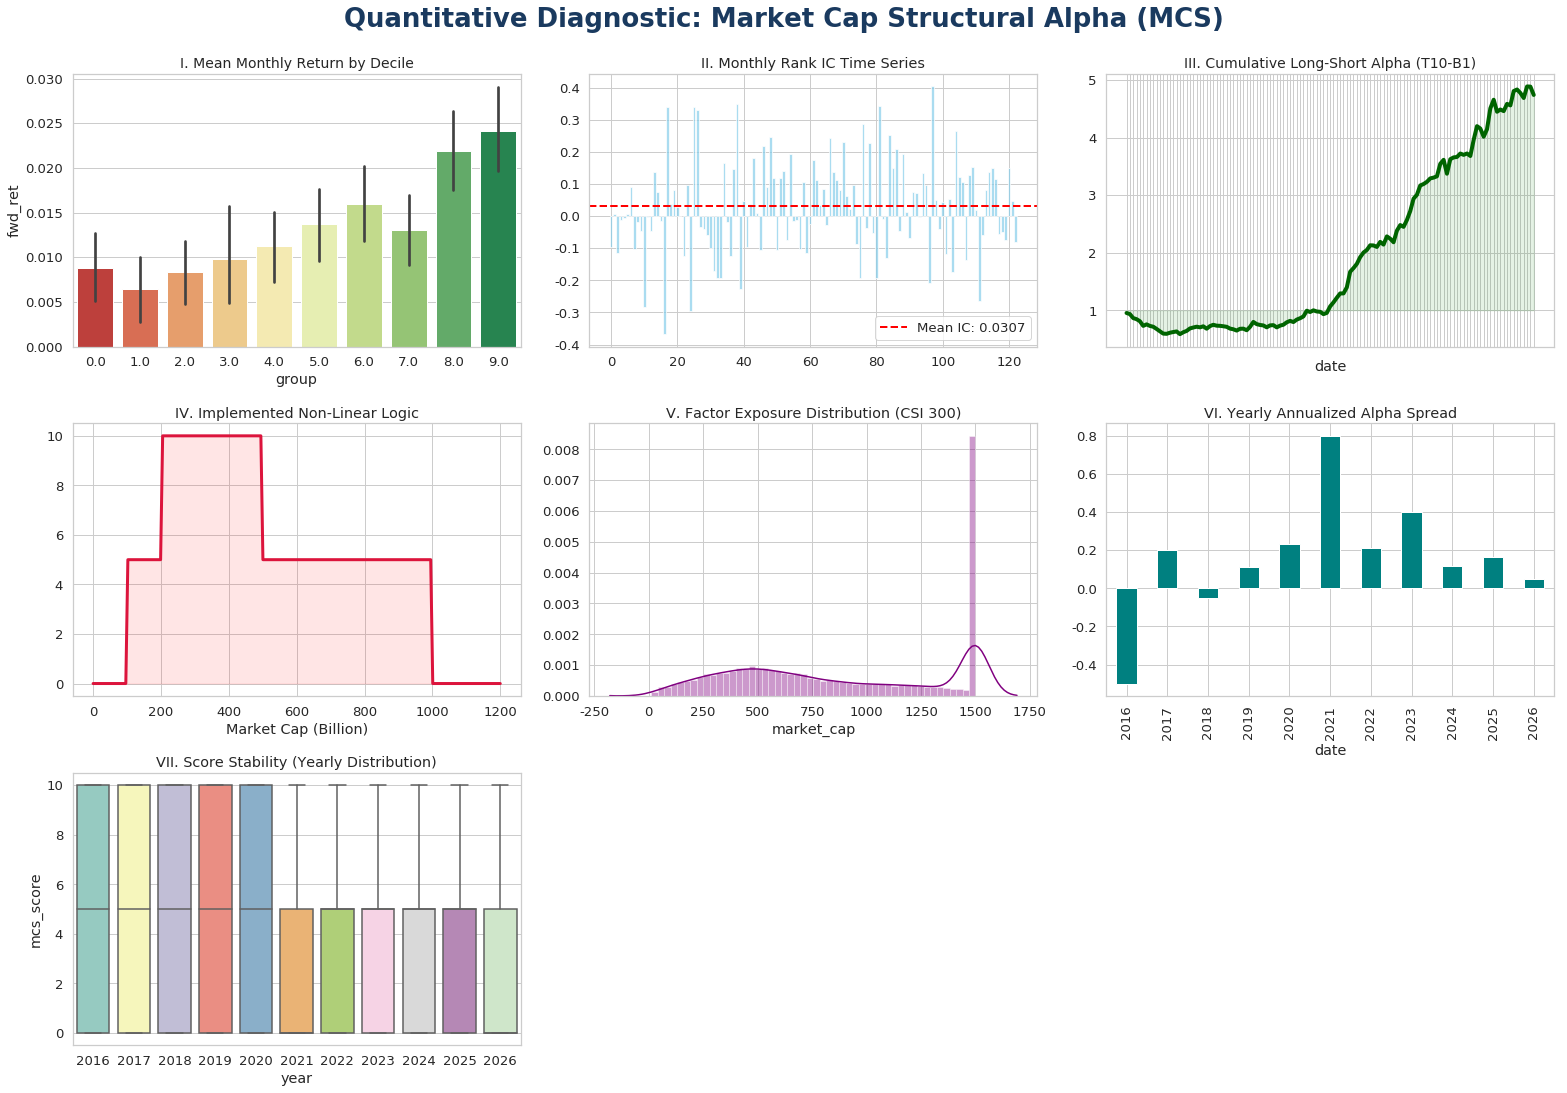


MCS FACTOR FINAL PERFORMANCE REPORT
------------------------------------------------------------
Mean Rank IC:        0.0307
IC Standard Dev:     0.1481
IC IR (Risk-Adj):    0.2072
Annualized Spread:   16.54%


In [4]:
"""
FACTOR RESEARCH REPORT: Market Cap Structural Alpha (MCS)
--------------------------------------------------------------------------------
INTRODUCTION:
The MCS factor is a non-linear quality-style factor designed to capture the 
"Mid-Cap Premium" within the A-share market. Unlike traditional linear size 
factors (SMB), MCS identifies a specific 'Sweet Spot' for investment:

1. CORE LOGIC: Targets stocks with a market capitalization between 20-50 Billion 
   CNY (Optimal), assigning them a full score of 10. These firms are viewed as 
   having the ideal balance of high growth potential and institutional liquidity.
   
2. BUFFER LOGIC: Stocks in the 10-20B and 50-100B ranges are assigned 5 points 
   (Acceptable), serving as a transition zone to mitigate turnover.
   
3. RISK AVERSION: Scores <100B (Shell risk) and >1000B (Growth stagnation) are 
   assigned 0 points to filter out structural laggards.
"""

# ==============================================================================
# 0. Environment & Visualization Setup
# ==============================================================================
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
from scipy.stats import spearmanr
import warnings

# Global Plotting Configuration
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams['axes.unicode_minus'] = False 

# ==============================================================================
# 1. Factor Construction (The Scoring Engine)
# ==============================================================================
def calculate_mcs_score(mkt_cap_bn):
    """
    Non-linear Scoring Model:
    Optimal Zone: [200, 500] -> 10.0
    Buffer Zone: [100, 200) or (500, 1000] -> 5.0
    Outside: 0.0
    """
    if pd.isna(mkt_cap_bn): return 0.0
    
    if 200 <= mkt_cap_bn <= 500:
        return 10.0
    elif (100 <= mkt_cap_bn < 200) or (500 < mkt_cap_bn <= 1000):
        return 5.0
    return 0.0

# ==============================================================================
# 2. Research Data Pipeline
# ==============================================================================
def get_factor_analytics_data(date, stocks):
    """
    Extracts market cap, applies scoring, and aligns with forward returns.
    """
    # Query raw Market Cap (Unit: 100M CNY / 亿元)
    q = query(valuation.code, valuation.market_cap).filter(valuation.code.in_(stocks))
    df = get_fundamentals(q, date=date)
    
    if df.empty: return pd.DataFrame()

    # Apply Factor Logic
    df['mcs_score'] = df['market_cap'].apply(calculate_mcs_score)
    # Apply Jitter to ensure unique binning boundaries for qcut
    df['score_jitter'] = df['mcs_score'] + np.random.normal(0, 1e-9, len(df))
    
    try:
        # Align T factor with T+1 Month returns
        next_m = (pd.to_datetime(date) + pd.DateOffset(months=1)).strftime('%Y-%m-%d')
        
        p_t = get_price(list(df['code']), count=1, end_date=date, fields='close', panel=False).set_index('code')['close']
        p_t_plus_1 = get_price(list(df['code']), count=1, end_date=next_m, fields='close', panel=False).set_index('code')['close']
        
        df['fwd_ret'] = df['code'].map((p_t_plus_1 / p_t) - 1)
        df['date'] = date
        return df.dropna(subset=['fwd_ret'])
    except:
        return pd.DataFrame()

# ==============================================================================
# 3. Execution Engine
# ==============================================================================
universe = get_index_stocks('000300.XSHG') # Testing on CSI 300 Universe
test_dates = pd.date_range(start='2016-01-01', end='2026-3-31', freq='MS').strftime('%Y-%m-%d').tolist()

print(f"Initiating Factor Backtest: {len(test_dates)} Periods | Universe: CSI 300")
master_results = []

for i, d in enumerate(test_dates):
    data_slice = get_factor_analytics_data(d, universe)
    if not data_slice.empty:
        master_results.append(data_slice)
    if (i+1) % 12 == 0:
        print(f"Status: {d} processed successfully.")

# ==============================================================================
# 4. Factor Intelligence Dashboard
# ==============================================================================
if master_results:
    final_df = pd.concat(master_results)
    final_df['year'] = pd.to_datetime(final_df['date']).dt.year
    
    fig = plt.figure(figsize=(22, 16))
    gs = fig.add_gridspec(3, 3)
    plt.suptitle("Quantitative Diagnostic: Market Cap Structural Alpha (MCS)", 
                 fontsize=26, fontweight='bold', color='#1a3a5f', y=0.98)

    # I. Monotonicity Test (Decile Analysis)
    ax1 = fig.add_subplot(gs[0, 0])
    final_df['group'] = final_df.groupby('date')['score_jitter'].transform(
        lambda x: pd.qcut(x, 10, labels=range(10), duplicates='drop'))
    sns.barplot(x='group', y='fwd_ret', data=final_df, palette='RdYlGn', ax=ax1)
    ax1.set_title("I. Mean Monthly Return by Decile", fontsize=14)

    # II. Rank IC Analysis (Predictive Strength)
    ax2 = fig.add_subplot(gs[0, 1])
    ic_series = final_df.groupby('date').apply(lambda x: spearmanr(x['mcs_score'], x['fwd_ret'])[0])
    ax2.bar(range(len(ic_series)), ic_series.values, color='skyblue', alpha=0.7)
    ax2.axhline(ic_series.mean(), color='red', ls='--', lw=2, label=f'Mean IC: {ic_series.mean():.4f}')
    ax2.set_title("II. Monthly Rank IC Time Series"); ax2.legend()

    # III. Cumulative Alpha (Long-Short Performance)
    ax3 = fig.add_subplot(gs[0, 2])
    g_ret = final_df.groupby(['date', 'group'])['fwd_ret'].mean().unstack()
    ls_return = (1 + (g_ret[g_ret.columns[-1]] - g_ret[g_ret.columns[0]])).cumprod()
    ls_return.plot(ax=ax3, lw=4, color='darkgreen')
    ax3.fill_between(ls_return.index, 1, ls_return.values, color='green', alpha=0.1)
    ax3.set_title("III. Cumulative Long-Short Alpha (T10-B1)", fontsize=14)

    # IV. Scoring Function Verification
    ax4 = fig.add_subplot(gs[1, 0])
    tx = np.linspace(0, 1200, 200); ty = [calculate_mcs_score(x) for x in tx]
    ax4.plot(tx, ty, color='crimson', lw=3); ax4.fill_between(tx, 0, ty, alpha=0.1, color='red')
    ax4.set_title("IV. Implemented Non-Linear Logic"); ax4.set_xlabel("Market Cap (Billion)")

    # V. Exposure Distribution
    ax5 = fig.add_subplot(gs[1, 1])
    sns.distplot(final_df['market_cap'].clip(0, 1500), bins=50, color='purple', ax=ax5)
    ax5.set_title("V. Factor Exposure Distribution (CSI 300)")

    # VI. Annualized Alpha Spread
    ax6 = fig.add_subplot(gs[1, 2])
    ((g_ret[g_ret.columns[-1]] - g_ret[g_ret.columns[0]]).groupby(pd.to_datetime(g_ret.index).year).mean() * 12).plot(kind='bar', color='teal')
    ax6.set_title("VI. Yearly Annualized Alpha Spread")

    # VII. Factor Stability
    ax7 = fig.add_subplot(gs[2, 0])
    sns.boxplot(x='year', y='mcs_score', data=final_df, palette='Set3', ax=ax7)
    ax7.set_title("VII. Score Stability (Yearly Distribution)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Performance Summary Statistics
    print("\n" + "="*60)
    print("MCS FACTOR FINAL PERFORMANCE REPORT")
    print("-" * 60)
    print(f"Mean Rank IC:        {ic_series.mean():.4f}")
    print(f"IC Standard Dev:     {ic_series.std():.4f}")
    print(f"IC IR (Risk-Adj):    {ic_series.mean()/ic_series.std():.4f}")
    print(f"Annualized Spread:   {(g_ret[g_ret.columns[-1]]-g_ret[g_ret.columns[0]]).mean()*1200:.2f}%")
    print("="*60)